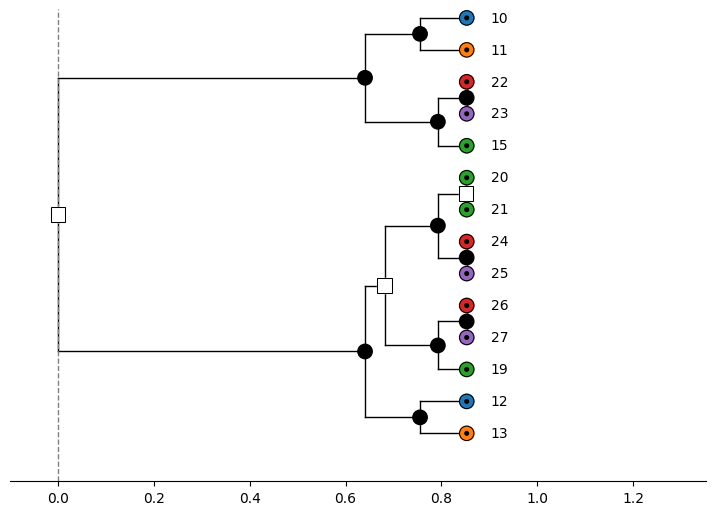

In [20]:
"""
Untersucht Brueche zwischen BMG = bmg(Network, mode="strong") und
BCBMG = bmg(BICcherryRestrict(BMG), mode="strong").

Mechanismus (Kriterium)
------------------------
Ein P-Knoten p_{x1,y1} wird GENAU DANN auf BEIDEN Seiten mit je einem
Q-Knoten erweitert, wenn weder (x1,y1) noch (y1,x1) im Ziel-BMG vorhanden
sind. Dabei entstehen zwei unabhaengige Q-Kinder:
    q_a: Kinder x1, y2   (y2 = Kandidat fuer x1's Korrektur)
    q_b: Kinder y1, x2   (x2 = Kandidat fuer y1's Korrektur)

p_{x1,y1} bleibt dabei ein gemeinsamer Vorfahre von x2 und y2 (via q_b bzw.
q_a) -- ZUSAETZLICH zu ihrer eigenen, unabhaengigen P-Cherry p_{x2,y2}.
Da p_{x1,y1} und p_{x2,y2} strukturell GESCHWISTER sind (beide direkte
Kinder von rho), dominiert keiner der beiden den anderen -- p_{x1,y1}
bleibt ein NICHT dominierter, "zusaetzlicher" LCA fuer das Paar (x2,y2).

Unter weak stoert das nicht (ein LCA reicht). Unter strong aber schon:
p_{x1,y1} ist zwar ein LCA von (x2,y2), gehoert aber (fast immer) NICHT
zu M(x2, Farbe(y2)) bzw. M(y2, Farbe(x2)) -- die Teilmengenbedingung
schlaegt fehl. Hatten x2 und y2 also urspruenglich (im Ziel-BMG) selbst
einen echten Match, geht dieser im BCBMG unter strong VERLOREN.

Voraussetzung: Tree, bmg(...), BICcherryRestrict(...), insertHybrid2(...)
sind bereits an anderer Stelle im Notebook definiert.
"""

# import stuff
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import MISC_Functions
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from collections import defaultdict
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg, bmg_fast
from MISC_Functions import biccherry, MultiLayerdBICCherry
from bmg_fun import convert_to_nx
from insert_hybrid import insertHybrid, insertHybrid2
from BICcherryRestrict import BICcherryRestrict
from asymmetree.analysis import bmg_from_tree, is_bmg



### Tree Generation

speciesTree, geneTree = MISC_Functions.generateTree(seed = 1, nSpecies = 5)
# Gute Kombinationen:
# (43,2), (1,5)


# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
BMG = bmg(Tree, mode = "strong")
BC = BICcherryRestrict(BMG)
BMGBC = bmg(BC, mode = "strong")

if not nx.utils.graphs_equal(BMG, BMGBC):
    print("the BMG already breaks for the Tree")

# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)


In [19]:
# =====================================================================
# 1. check_criteria: NUR das oben beschriebene Kriterium
# =====================================================================

def check_criteria(BMG: nx.DiGraph):
    """
    Prueft auf das strong-spezifische Bruchkriterium: doppelt korrigierte
    P-Knoten, deren beide Korrektur-Kandidaten (x2, y2) selbst einen
    echten Match im Ziel-BMG haben -- dieser geht im BCBMG unter strong
    verloren.

    Parameters
    ----------
    BMG : networkx.DiGraph
        Das zu pruefende Ziel-BMG (i.d.R. mode="strong"). Jeder Knoten
        braucht ein "color"-Attribut.

    Returns
    -------
    has_break : bool
        True, wenn mindestens ein Fall gefunden wurde.
    breaks : list[dict]
        Alle gefundenen Faelle, je mit den Schluesseln:
        "x1", "y1"  -- das doppelt korrigierte P-Knoten-Paar,
        "x2", "y2"  -- die betroffenen Kandidaten mit echtem Match,
        "direction" -- "x2->y2", "y2->x2" oder "both", je nachdem welche
                       Richtung(en) im Ziel-BMG vorhanden sind (und damit
                       im BCBMG verloren gehen).
    """
    breaks = []
    nodes = list(BMG.nodes())

    for x1, y1 in ((a, b) for a in nodes for b in nodes if a < b):
        color_x1 = BMG.nodes[x1]["color"]
        color_y1 = BMG.nodes[y1]["color"]
        if color_x1 == color_y1:
            continue

        # p_x1y1 wird nur dann beidseitig korrigiert, wenn BEIDE Richtungen fehlen
        if BMG.has_edge(x1, y1) or BMG.has_edge(y1, x1):
            continue

        candidates_x2 = [
            x2 for x2 in BMG.successors(y1)
            if BMG.nodes[x2]["color"] == color_x1
        ]
        candidates_y2 = [
            y2 for y2 in BMG.successors(x1)
            if BMG.nodes[y2]["color"] == color_y1
        ]
        if not candidates_x2 or not candidates_y2:
            continue  # kein gueltiger Kandidat -- separates Problem, siehe check_criteria (weak)

        for x2 in candidates_x2:
            for y2 in candidates_y2:
                fwd = BMG.has_edge(x2, y2)
                bwd = BMG.has_edge(y2, x2)
                if fwd or bwd:
                    direction = "both" if (fwd and bwd) else ("x2->y2" if fwd else "y2->x2")
                    breaks.append({
                        "x1": x1, "y1": y1,
                        "x2": x2, "y2": y2,
                        "direction": direction,
                    })

    return len(breaks) > 0, breaks


# =====================================================================
# 2. Haupt-Experiment (Ablauf wie beschrieben, durchgehend "strong")
# =====================================================================

def run_strong_experiment(Tree, runs: int = 100, max_hybrids: int = 100, seed: int = 0):
    """
    Ablauf pro Run:
      1) Network = Tree, dann schrittweise Hybriden einfuegen.
      2) BMG = bmg(Network, mode="strong")
      3) BC = BICcherryRestrict(BMG)
      4) BCBMG = bmg(BC, mode="strong")
      5) Vergleiche BMG mit BCBMG; parallel dazu check_criteria(BMG)
         als Vorhersage.

    Returns
    -------
    events : list[dict]  -- ein Eintrag pro Hybrid-Insertion
    hybrids_before_break : list[int]  -- nur fuer echte (nicht zensierte) Breaks
    """
    random.seed(seed)

    events = []
    hybrids_before_break = []

    for i in range(runs):
        Network = copy.deepcopy(Tree)
        BMG = bmg(Tree, mode="strong")
        BC = BICcherryRestrict(BMG)
        BCBMG = bmg(BC, mode="strong")

        count = 0
        broke = False

        while nx.utils.graphs_equal(BMG, BCBMG) and count < max_hybrids:
            Network, combinedNodes = insertHybrid2(Network)
            BMG = bmg(Network, mode="strong")
            BC = BICcherryRestrict(BMG)
            BCBMG = bmg(BC, mode="strong")
            count += 1

            broke = not nx.utils.graphs_equal(BMG, BCBMG)
            predicted_break, break_instances = check_criteria(BMG)

            events.append({
                "run": i, "hybrid_index": count,
                "broke": broke, "predicted_break": predicted_break,
                "n_break_instances": len(break_instances),
                "break_instances": break_instances,
                "missing_in_BCBMG": set(BMG.edges()) - set(BCBMG.edges()),
                "extra_in_BCBMG": set(BCBMG.edges()) - set(BMG.edges()),
            })

        if broke:
            hybrids_before_break.append(count)

    return events, hybrids_before_break


def print_summary(events, hybrids_before_break, runs):
    tp = sum(e["broke"] and e["predicted_break"] for e in events)
    fn = sum(e["broke"] and not e["predicted_break"] for e in events)
    fp = sum((not e["broke"]) and e["predicted_break"] for e in events)
    tn = sum((not e["broke"]) and not e["predicted_break"] for e in events)

    print("=== Hypothese: doppelt korrigierter P-Knoten mit echtem (x2,y2)-Match => strong-Bruch ===")
    print(f"TP: {tp}   FN: {fn}   FP: {fp}   TN: {tn}")
    if tp + fn:
        print(f"Recall:    {tp/(tp+fn):.2%}")
    if tp + fp:
        print(f"Precision: {tp/(tp+fp):.2%}")
    if fn == 0 and fp == 0:
        print(">>> Hypothese trifft auf ALLE Ereignisse exakt zu.")

    print(f"\nEchte (nicht zensierte) Breaks: {len(hybrids_before_break)} / {runs}")
    if hybrids_before_break:
        print(f"Oe Hybriden bis Break:          {np.mean(hybrids_before_break):.2f}")


if not nx.utils.graphs_equal(BMG, BMGBC):
    print("the BMG already breaks for the Tree")

if __name__ == "__main__":
    events, hybrids_before_break = run_strong_experiment(Tree, runs=100, max_hybrids=100, seed=0)
    print_summary(events, hybrids_before_break, runs=100)

=== Hypothese: doppelt korrigierter P-Knoten mit echtem (x2,y2)-Match => strong-Bruch ===
TP: 100   FN: 0   FP: 2   TN: 55
Recall:    100.00%
Precision: 98.04%

Echte (nicht zensierte) Breaks: 100 / 100
Oe Hybriden bis Break:          1.57


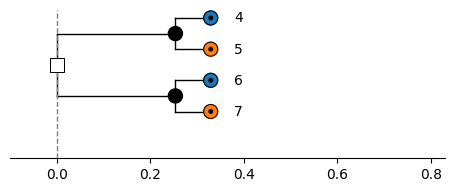

In [9]:
# import stuff
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import MISC_Functions
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from collections import defaultdict
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg, bmg_fast
from MISC_Functions import biccherry, MultiLayerdBICCherry
from bmg_fun import convert_to_nx
from insert_hybrid import insertHybrid, insertHybrid2
from BICcherryRestrict import BICcherryRestrict
from asymmetree.analysis import bmg_from_tree, is_bmg



### Tree Generation

speciesTree, geneTree = MISC_Functions.generateTree(seed = 43, nSpecies = 2)
# Gute Kombinationen:
# (43,2), (1,5)
# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
BMG = bmg(Tree)
BC = BICcherryRestrict(BMG)
BMGBC = bmg(BC)

if not nx.utils.graphs_equal(BMG, BMGBC):
    print("the BMG already breaks for the Tree")

Es konnten 1 Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten
{('4', '7'), ('7', '4')}


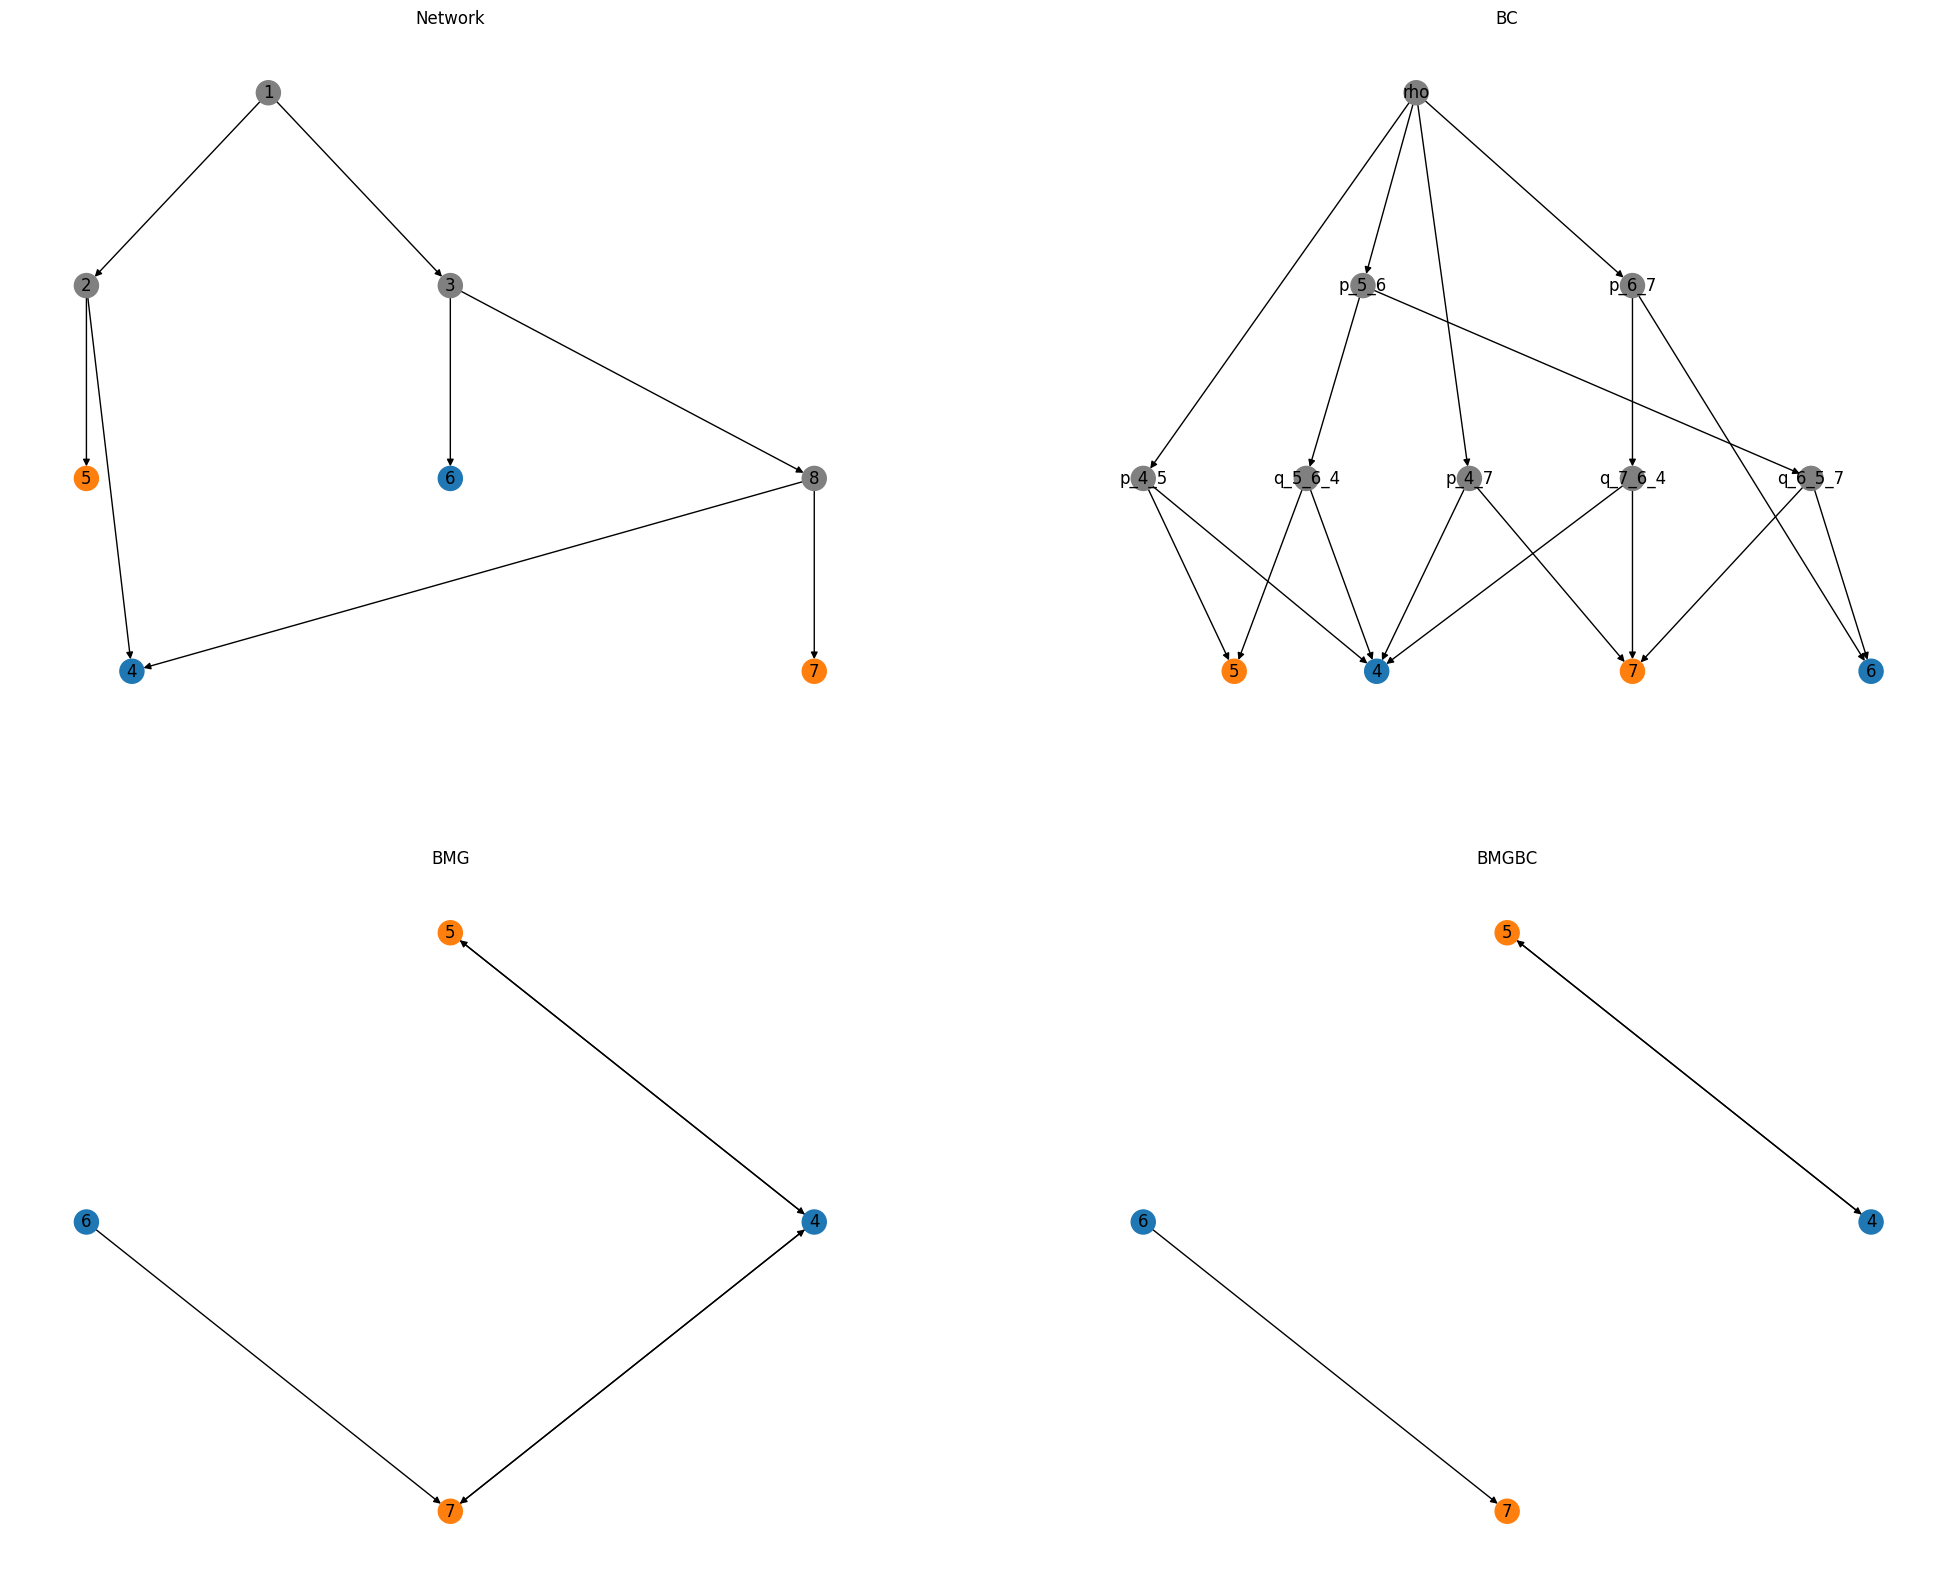

In [10]:
# Testen, wie viele Hybride man einfügen kann, bevor die beiden BMGs nicht mehr übereinstimmen
# random.seed(6)
mode = "strong"
count = 0
Network = copy.deepcopy(Tree)
BMG = bmg(Tree)
# BC = MultiLayerdBICCherry(BMG)
BC = BICcherryRestrict(BMG)
BMGBC = bmg(BC)

while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
    Network,combinedNodes = insertHybrid2(Network)
    BMG = bmg(Network, mode = mode)
    # BC = MultiLayerdBICCherry(BMG)
    BC = BICcherryRestrict(BMG)
    BMGBC = bmg(BC, mode = mode)
    count += 1
    # if count % 10 == 0:
    #     print("Count = ",count)

    # prüfen, ob der zuletzt generierte Hybrid 2 leaves unterschiedlicher Farbe sind
    # node1 = combinedNodes[0]
    # node2 = combinedNodes[1]

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color']:
    #     print("Durch den Hybrid wurden zwei Äste unterschiedlicher Farbe direkt verbunden")

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color'] and Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0:
    #     print("Durch den Hybrid wurden zwei Blätter unterschiedlicher Farbe direkt verbunden")

print("Es konnten",count,"Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten")


# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

# visualize tree and network
fig, axes = plt.subplots(2, 2, figsize=(25, 20))

pos = graphviz_layout(Network, prog="dot")
nodes_list = [v for v in Network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(Network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,0])
axes[0,0].set_title("Network")

pos = graphviz_layout(BC, prog="dot")
nodes_list = [v for v in BC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BC, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,1])
axes[0,1].set_title("BC")


nodes_list = [v for v in BMG.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,0].set_title("BMG")
nx.draw(BMG, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels=True)


nodes_list = [v for v in BMGBC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,1].set_title("BMGBC")
nx.draw(BMGBC, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True)

print(BMG.edges - BMGBC.edges)


In [3]:
BC.has_edge('p_11_9','9')

True

In [4]:
 # trees = 100  # Mehrere unterschiedliche random Bäume generieren und alle testen
runs = 100
mode = "weak"
hybridsBeforeBreak = np.empty(runs)
casesWithBreak = 0
casesWithoutBreak = 0

for i in range(runs):

    count = 0
    Network = copy.deepcopy(Tree)
    BMG = bmg(Tree)
    # BC = MultiLayerdBICCherry(BMG)
    BC = BICcherryRestrict(BMG)
    BMGBC = bmg(BC)

    while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
        Network,combinedNodes = insertHybrid2(Network)
        BMG = bmg(Network, mode = mode)
        # BC = MultiLayerdBICCherry(BMG)
        BC = BICcherryRestrict(BMG)
        BMGBC = bmg(BC, mode = mode)
        count += 1
    
        # prüfen, ob der zuletzt generierte Hybrid 2 leaves unterschiedlicher Farbe sind
        node1 = combinedNodes[0]
        node2 = combinedNodes[1]

        if (Network.nodes[node1]['color'] != Network.nodes[node2]['color'] and  #check wether both connected nodes have a different colour
        Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0 and   #check wether both connected nodes are leaves 
        nx.utils.graphs_equal(BMG, BMGBC) and                                   #check wether the BMGs still are the same
        (BMG.has_edge(node1,node2) ^ BMG.has_edge(node2,node1))):               #check wether the best match is only in one direction
            casesWithoutBreak += 1

        # elif Network.out_degree(node1) > 0 and Network.out_degree(node2) == 0 and all(Network.out_degree(succ) == 0 for succ in Network.successors(node1)) and nx.utils.graphs_equal(BMG, BMGBC):

        #     # check ob alle Blätter die gleiche Farbe haben und ob diese Farbe unterschiedlich von node2 ist
        #     clrs = {Network.nodes[s].get("color") for s in Network.successors(node1)}

        #     if len(clrs) == 1 and Network.nodes[node2]["color"] not in clrs:
        #         casesWithoutBreak += 1

        # elif Network.out_degree(node2) > 0 and Network.out_degree(node1) == 0 and all(Network.out_degree(succ) == 0 for succ in Network.successors(node2)) and nx.utils.graphs_equal(BMG, BMGBC):

        #     # check ob alle Blätter die gleiche Farbe haben und ob diese Farbe unterschiedlich von node2 ist
        #     clrs = {Network.nodes[s].get("color") for s in Network.successors(node2)}

        #     if len(clrs) == 1 and Network.nodes[node1]["color"] not in clrs:
        #         casesWithoutBreak += 1

    if Network.nodes[node1]['color']!=Network.nodes[node2]['color'] and Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0:
        casesWithBreak += 1

    elif Network.out_degree(node1) > 0 and Network.out_degree(node2) == 0 and all(Network.out_degree(succ) == 0 for succ in Network.successors(node1)):

        # check ob alle Blätter die gleiche Farbe haben und ob diese Farbe unterschiedlich von node2 ist
        clrs = {Network.nodes[s].get("color") for s in Network.successors(node1)}

        if len(clrs) == 1 and Network.nodes[node2]["color"] not in clrs:
            casesWithBreak += 1

    elif Network.out_degree(node2) > 0 and Network.out_degree(node1) == 0 and all(Network.out_degree(succ) == 0 for succ in Network.successors(node2)):

        # check ob alle Blätter die gleiche Farbe haben und ob diese Farbe unterschiedlich von node2 ist
        clrs = {Network.nodes[s].get("color") for s in Network.successors(node2)}

        if len(clrs) == 1 and Network.nodes[node1]["color"] not in clrs:
            casesWithBreak += 1


            
    hybridsBeforeBreak[i] = count

print("average inserted Hybrids before break:",np.average(hybridsBeforeBreak))
print("Cases in which the last hybrid connected two different colored leaves directly",casesWithBreak,"and the BMGs broke")
print("There were",casesWithoutBreak,"Cases, where it didn't break the BMGs")


average inserted Hybrids before break: 1.82
Cases in which the last hybrid connected two different colored leaves directly 98 and the BMGs broke
There were 0 Cases, where it didn't break the BMGs
